# Titanic Survival Predictor with Random Forest and XGBoost
#### -Pranjal Sapkota

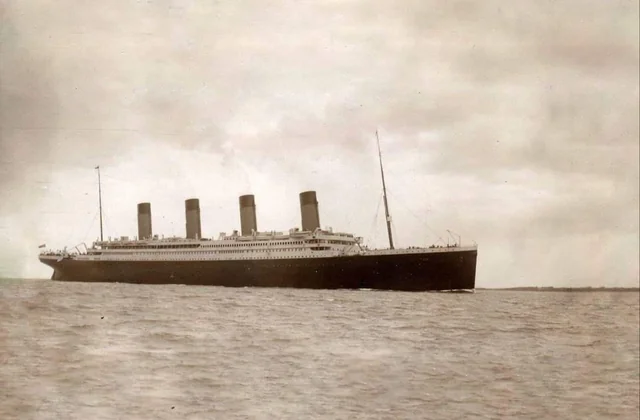
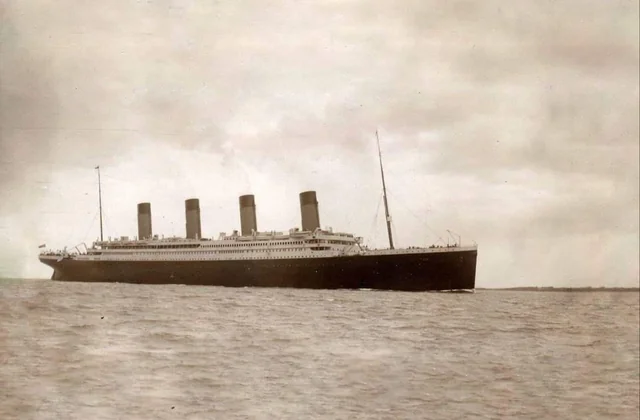

This notebook predicts the survival of a passenger according to various factors, boarded in the RMS Titanic disaster (April 15, 1912).
## Table of Content
1. Environmental Setup
2. Loading Dataset
3. Initial Data Cleaning
4. Encode categorical variables
5. Define features and target
6. Split dataset
7. Train models
8. Evaluate models
9. Analyzing feature importance
10. Improving model
11. Cross validation and confusion matrix
12. Create input sample

## 1. Environmental Setup

In [1]:
import numpy as np 
import pandas as pd
from sklearn.ensemble import RandomForestClassifier # Model
from sklearn.metrics import accuracy_score # error percentage calculator
from sklearn.model_selection import train_test_split # splitting data to training and validation
from sklearn.pipeline import Pipeline # combines multiple data preprocessing steps (transformers) and a machine learning model (estimator) into a single, cohesive object.  
from xgboost import XGBClassifier # Model
from sklearn.preprocessing import OneHotEncoder # categorical value encoder
from sklearn.compose import ColumnTransformer # column transformer for categorical encoding
from sklearn.inspection import permutation_importance # feature importance
from sklearn.metrics import confusion_matrix # Interpreting cross validation
from sklearn.model_selection import cross_val_predict # cross validation
from sklearn.model_selection import cross_val_score # cross validation scoring

import pickle # For saving the model

## 2. Loading Dataset

In [2]:
data = pd.read_csv("./titanic.csv")

## 3. Initial Data Cleaning

In [3]:
print(data.shape)
data.head()
data.info()
data.describe()

(891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
data = data.drop(['Cabin', 'Name', 'PassengerId', 'Ticket'], axis=1)
data['Age'] = data['Age'].fillna(data['Age'].median())
data = data.dropna(subset=['Embarked'])
data.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

## 4. Encoding categorical variables

In [6]:
categorical_cols = ['Sex', 'Embarked']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

## 5. Define features and target

In [7]:
X = data.drop(['Survived'], axis=1)
y = data['Survived']

## 6. Split Dataset

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

## 7. Train models

In [9]:
# Using random forest
model1 = RandomForestClassifier()
pipeline1 = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model1)
])

# Using XGBoost
model2 = XGBClassifier()
pipeline2 = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model2)
])

pipeline1.fit(X_train, y_train)    
pipeline2.fit(X_train, y_train)
print("Model training done")

Model training done


## 8. Evaluate models

In [10]:
# 1 for random forest, 2 for XGBoost
preds1 = pipeline1.predict(X_test)
preds2 = pipeline2.predict(X_test)

accuracy1 = accuracy_score(y_test, preds1)
accuracy2 = accuracy_score(y_test, preds2)

print(f"Accuracy for Random Forest: {accuracy1*100:.2f}% \nAccuracy for XGBoost: {accuracy2*100:.2f}%")

Accuracy for Random Forest: 75.84% 
Accuracy for XGBoost: 76.97%


## 9. Analyzing Feature importance

In [11]:
result = permutation_importance(
    pipeline1, X_test, y_test, n_repeats=10, random_state=0
)
importance = pd.Series(result.importances_mean, index=X_test.columns)
importance = importance.sort_values(ascending=False)
print(importance)

Sex         0.125281
Pclass      0.060112
Age         0.026404
Fare        0.014045
Embarked    0.012360
SibSp       0.004494
Parch      -0.003933
dtype: float64


## 10. Improving model

As we can see, Embarked, Siblings/Spouse and Parent/Children has very low impact on the prediction and hence creating noise.
Lets remove these features and rerun the predictions.
Lets add features to our models as well.

In [12]:
categorical_cols = ['Sex']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

X = data.drop(['Survived', 'Embarked', 'SibSp', 'Parch'], axis=1)
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Using random forest
model1 = RandomForestClassifier(
    n_estimators=300, 
    max_depth=9, 
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=0
)
pipeline1 = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model1)
])

# Using XGBoost
model2 = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0
)
pipeline2 = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model2)
])

pipeline1.fit(X_train, y_train)    
pipeline2.fit(X_train, y_train)

preds1 = pipeline1.predict(X_test)
preds2 = pipeline2.predict(X_test)

accuracy3 = accuracy_score(y_test, preds1)
accuracy4 = accuracy_score(y_test, preds2)

print(f"Accuracy for Random Forest: {accuracy3*100:.2f}% (improved by {((accuracy3 - accuracy1)*100):.2f}%)\nAccuracy for XGBoost: {accuracy4*100:.2f}% (improved by {((accuracy4 - accuracy2)*100):.2f}%)")

Accuracy for Random Forest: 80.34% (improved by 4.49%)
Accuracy for XGBoost: 82.02% (improved by 5.06%)


## 11. Cross validation and confusion matrix

In [13]:
y_pred1 = cross_val_predict(pipeline1, X, y, cv=5)
y_pred2 = cross_val_predict(pipeline2, X, y, cv=5)

print("For random forest:")
print(f"True Negative: {confusion_matrix(y, y_pred1)[0][0]}")
print(f"True Positive: {confusion_matrix(y, y_pred1)[1][1]}")
print(f"False Negative: {confusion_matrix(y, y_pred1)[1][0]}")
print(f"False Positive: {confusion_matrix(y, y_pred1)[0][1]}\n")
print("For XGBoost:")
print(f"True Negative: {confusion_matrix(y, y_pred2)[0][0]}")
print(f"True Positive: {confusion_matrix(y, y_pred2)[1][1]}")
print(f"False Negative: {confusion_matrix(y, y_pred2)[1][0]}")
print(f"False Positive: {confusion_matrix(y, y_pred2)[0][1]}\n")

scores1 = cross_val_score(pipeline1, X, y, cv=5, scoring="accuracy")
print(f"Cross validation accuracy for Random Forest: {(scores1.mean()*100):.2f}% ±{scores1.std():.2f}%")
scores2 = cross_val_score(pipeline2, X, y, cv=5, scoring="accuracy")
print(f"Cross validation accuracy for XGBoost: {(scores2.mean()*100):.2f}% ±{scores2.std():.2f}%")

For random forest:
True Negative: 496
True Positive: 246
False Negative: 94
False Positive: 53

For XGBoost:
True Negative: 490
True Positive: 248
False Negative: 92
False Positive: 59

Cross validation accuracy for Random Forest: 83.47% ±0.02%
Cross validation accuracy for XGBoost: 83.02% ±0.02%


Save the trained model

In [14]:
pickle.dump(pipeline2, open("model.pkl", "wb"))

## 12. Creating Sample input
try out some sample inputs yourself

In [ ]:
# Find out the avg fare price for that class first
category = int(input("Enter Ticket class: ")) # 1 = First (upper), 2 = Second (middle), 3 = Third (lower)
sex = input("Enter Sex (male/female): ")
age = int(input("Enter Age: "))

fare_avg = data[data['Pclass'] == category]['Fare'].mean()

sample = pd.DataFrame({
    'Pclass': [category],
    'Sex': [sex],
    'Age': [age],
    'Fare': [fare_avg],
})

prediction = pipeline2.predict(sample)
if prediction[0] == 1:
    print("Survived")
else:
    print("Did not survive")

13.675550101832993
Did not survive
